[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/langchain-ai/langchain-academy/blob/main/module-3/dynamic-breakpoints.ipynb) [![Open in LangChain Academy](https://cdn.prod.website-files.com/65b8cd72835ceeacd4449a53/66e9eba12c7b7688aa3dbb5e_LCA-badge-green.svg)](https://academy.langchain.com/courses/take/intro-to-langgraph/lessons/58239526-lesson-4-dynamic-breakpoints)

# Dynamic breakpoints 

## 回顧

我們討論過導入 human-in-the-loop 的幾個動機：

(1) `Approval`（核准）- 我們可以中斷 agent，把 state 呈現給使用者，並讓使用者決定是否接受某個動作

(2) `Debugging`（除錯）- 我們可以倒帶 graph，藉此重現或避開問題

(3) `Editing`（編輯）- 你可以修改 state 

我們把 breakpoint 當成一種讓 graph 在特定步驟停下來的通用做法，這就能支援像 `Approval` 這樣的使用情境

我們也示範了如何編輯 graph state，並引入人類的回饋。

## 目標

Breakpoint 是由開發者在 graph 編譯時，設定在某個特定 node 上的。

但有時候，讓 graph 能**動態地中斷（dynamically interrupt）**自己也很有幫助！

這是一種內部的 breakpoint，可以透過 `NodeInterrupt` 來達成。

這帶來幾個具體的好處：

(1) 你可以有條件地觸發它（在 node 內部，依據開發者自訂的邏輯來判斷）。

(2) 你可以告訴使用者為什麼會中斷（透過把你想傳的任何內容傳給 `NodeInterrupt`）。

接下來，我們要建立一個 graph，當輸入的長度達到某個門檻時，就會丟出 `NodeInterrupt`。

In [ ]:
%%capture --no-stderr
%pip install --quiet -U langgraph langchain_openai langgraph_sdk

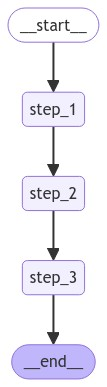

In [1]:
from IPython.display import Image, display

from typing_extensions import TypedDict
from langgraph.checkpoint.memory import MemorySaver
# ⚠️ 踩雷：NodeInterrupt 從 LangGraph v1.0 起已被標記 deprecated，現行 1.x 版本跑
#    這支 notebook 會噴 DeprecationWarning（程式照跑，不影響教學）。官方建議的新寫法是
#    langgraph.types.interrupt()。教材是舊版錄的，學員自己開新專案時要知道有這回事。
from langgraph.errors import NodeInterrupt
from langgraph.graph import START, END, StateGraph

class State(TypedDict):
    input: str

def step_1(state: State) -> State:
    print("---Step 1---")
    return state

def step_2(state: State) -> State:
    # 【本章核心對照組】NodeInterrupt（動態） vs 上一章的 interrupt_before（靜態）：
    #
    #   interrupt_before=["step_2"] → compile 時就定死，每次跑到 step_2 都停，
    #                                 由站在 graph 外面的開發者決定。
    #   raise NodeInterrupt(...)    → 執行時 node 自己看著 state 決定停不停。
    #
    # 「動態」的意思全在下面這個 if 裡：判斷條件寫在 node 內部，看了 state 內容才知道
    # 要不要停。同一個 graph，輸入 "hi" 一路通過，輸入 "hello world" 就停在這。
    if len(state['input']) > 5:
        # 為什麼是 raise？這是全章最反 Python 直覺的一行。
        # 它長得像例外，行為卻不是例外：LangGraph 會把 NodeInterrupt 攔下來，翻譯成一個
        # 「暫停點」，state 照樣存進 checkpoint，graph 不會崩潰、也不會炸到呼叫端臉上。
        # 一般 Python 的 raise ＝「出事了」；這裡的 raise ＝「我要暫停，等人來處理」。
        # 括號裡的字串不是錯誤訊息，是「停下來的理由」，等一下會在 state.tasks 裡被讀到。
        raise NodeInterrupt(f"Received input that is longer than 5 characters: {state['input']}")
    
    print("---Step 2---")
    return state

def step_3(state: State) -> State:
    print("---Step 3---")
    return state

builder = StateGraph(State)
builder.add_node("step_1", step_1)
builder.add_node("step_2", step_2)
builder.add_node("step_3", step_3)
builder.add_edge(START, "step_1")
builder.add_edge("step_1", "step_2")
builder.add_edge("step_2", "step_3")
builder.add_edge("step_3", END)

# 前提：沒有 checkpointer 就沒有 breakpoint（不管靜態還動態）。
# 「暫停」的本質是「把 state 存檔後停手、等人來接」——沒地方存檔，就只有跑完或崩潰兩條路。
# MemorySaver 存在記憶體裡，kernel 一重開全部消失；正式環境會換成 SqliteSaver/PostgresSaver。
memory = MemorySaver()
graph = builder.compile(checkpointer=memory)

display(Image(graph.get_graph().draw_mermaid_png()))

我們用一個長度超過 5 個字元的輸入來執行這個 graph。

In [2]:
initial_input = {"input": "hello world"}
thread_config = {"configurable": {"thread_id": "1"}}

# 跑到第一次中斷為止。
# ⚠️ 反直覺：step_2 明明 raise 了，這個 for 迴圈卻是「正常結束」的——沒有任何 exception
#    冒出來，NodeInterrupt 被框架整個吃掉了。所以「跑完了」和「停在半路」從迴圈本身
#    完全看不出差別，唯一的分辨方法是下一格的 state.next。
# 看輸出：只印到 ---Step 1---，step_2 裡的 print 一個字都沒出現，因為 raise 發生在它之前。
for event in graph.stream(initial_input, thread_config, stream_mode="values"):
    print(event)

{'input': 'hello world'}
---Step 1---
{'input': 'hello world'}


如果我們在這個時間點檢視 graph 的 state，會看到接下來要執行的 node 被設定為 `step_2`。


In [3]:
# state.next = 「下一站要跑哪個 node」。這裡是 ('step_2',)：
# step_2 raise 了就不算跑完，指標還卡在它身上，續跑時會從頭再跑一次 step_2。
# 這是判斷 graph 停住還是跑完的唯一依據：next 是空的 () ＝ 真的跑完；有東西 ＝ 停在半路。
state = graph.get_state(thread_config)
print(state.next)

('step_2',)


我們可以看到 `Interrupt` 被記錄到了 state 裡。

In [4]:
# next 和 tasks 的分工（教材把兩者放在相鄰 cell，卻沒說差在哪）：
#   state.next  → 只回答「停在哪」，就一個 node 名字。
#   state.tasks → 回答「為什麼停」。輸出裡的
#                 interrupts=(Interrupt(value='Received input that is longer than 5
#                 characters: hello world'),) 就是我們剛才 raise 時塞進去的那句話。
# 這正是動態 breakpoint 勝過 interrupt_before 的地方：靜態的只能讓你知道「停了」，
# 動態的可以夾帶理由，直接丟給前端或使用者看。
print(state.tasks)

(PregelTask(id='6eb3910d-e231-5ba2-b25e-28ad575690bd', name='step_2', error=None, interrupts=(Interrupt(value='Received input that is longer than 5 characters: hello world', when='during'),), state=None),)


我們可以試著從 breakpoint 恢復執行這個 graph。

但這樣只會把同一個 node 再跑一次！

除非 state 有所改變，否則我們會一直卡在這裡。

In [5]:
# 第一個參數傳 None ＝「沒有新輸入，從 checkpoint 存檔接著跑」，不是重跑一次 graph。
#
# ⚠️ 踩雷（教材完全沒寫，但這是本章最容易翻車的地方）：state 沒改就直接續跑＝原地打轉。
#    續跑會從頭再執行一次 step_2，而 input 還是那個 "hello world"，len > 5 依然成立
#    → 再次 raise NodeInterrupt，又停在同一個點。看輸出：只吐了一筆
#    {'input': 'hello world'}，---Step 2--- 還是沒印出來。
#    NodeInterrupt 不像 interrupt_before 那樣「停一次就放行」；觸發條件不解除就永遠過不去。
for event in graph.stream(None, thread_config, stream_mode="values"):
    print(event)

{'input': 'hello world'}


In [6]:
# 證據：續跑一輪之後 next 還是 ('step_2',)，一步都沒前進。
state = graph.get_state(thread_config)
print(state.next)

('step_2',)


現在，我們可以更新 state。

In [7]:
# 解法不是想辦法「跳過」interrupt，而是把觸發它的原因（state 內容）改掉。
# "hi" 只有 2 個字元，下次跑 step_2 時 len > 5 不成立，自然就過了。
#
# update_state 不會移動 next 指標，它只改 state 的內容——所以續跑時 step_2 仍然從頭
# 再跑一次，只是這次帶著新的 input 通過檢查。
# 回傳值是一個新的 checkpoint config（注意多了 checkpoint_id）：每次改 state 都是寫一筆
# 新存檔，原本那筆 "hello world" 還留在時間線上，沒有被覆蓋掉。
graph.update_state(
    thread_config,
    {"input": "hi"},
)

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1ef6a434-06cf-6f1e-8002-0ea6dc69e075'}}

In [8]:
# 一模一樣的 stream(None, ...) 再跑一次，這次一路通到底（---Step 2--- ---Step 3--- 都印出來了）。
# 差別只在 state 被改過。動態 breakpoint 的完整循環到這裡走完一圈：
#   撞停 → 看 state.tasks 知道為什麼停 → update_state 修掉原因 → stream(None) 續跑。
for event in graph.stream(None, thread_config, stream_mode="values"):
    print(event)

{'input': 'hi'}
---Step 2---
{'input': 'hi'}
---Step 3---
{'input': 'hi'}


### 搭配 LangGraph API 使用

**⚠️ 注意**

在拍攝這些影片之後，我們更新了 Studio，現在它已經可以在本機執行，並透過你的瀏覽器存取。這是執行 Studio 的建議方式，取代影片中所示範的 Desktop App。它現在叫做 _LangSmith Studio_，而不是 _LangGraph Studio_。詳細的設定說明可以在課程一開始的「Getting Setup」指南中找到。你可以在[這裡](https://docs.langchain.com/langsmith/studio)看到 Studio 的說明，本機部署的具體細節則在[這裡](https://docs.langchain.com/langsmith/quick-start-studio#local-development-server)。  
若要啟動本機開發伺服器，請在這個 module 的 `/studio` 目錄下，於你的終端機執行以下指令：

```
langgraph dev
```

你應該會看到以下輸出：
```
- 🚀 API: http://127.0.0.1:2024
- 🎨 Studio UI: https://smith.langchain.com/studio/?baseUrl=http://127.0.0.1:2024
- 📚 API Docs: http://127.0.0.1:2024/docs
```

打開你的瀏覽器，前往上方顯示的 **Studio UI** 網址。

In [1]:
if 'google.colab' in str(get_ipython()):
    raise Exception("Unfortunately LangGraph Studio is currently not supported on Google Colab")

我們透過 SDK 連線到它。

In [2]:
from langgraph_sdk import get_client

# 這是本機開發伺服器的網址
URL = "http://127.0.0.1:2024"
client = get_client(url=URL)

# 搜尋所有託管的 graph
assistants = await client.assistants.search()

In [12]:
thread = await client.threads.create()
input_dict = {"input": "hello world"}

async for chunk in client.runs.stream(
    thread["thread_id"],
    assistant_id="dynamic_breakpoints",
    input=input_dict,
    stream_mode="values",):
    
    print(f"Receiving new event of type: {chunk.event}...")
    print(chunk.data)
    print("\n\n")

Receiving new event of type: metadata...
{'run_id': '1ef6a43a-1b04-64d0-9a79-1caff72c8a89'}



Receiving new event of type: values...
{'input': 'hello world'}



Receiving new event of type: values...
{'input': 'hello world'}





In [13]:
current_state = await client.threads.get_state(thread['thread_id'])

In [14]:
# 對照組：SDK 版和本機版是同一套心智模型，只是搬到 HTTP API 上。
#   graph.get_state(cfg).next  ←→  current_state['next']
# （差別只在 SDK 回傳的是純 dict，所以用 ['next'] 取值，不是 .next）
current_state['next']

['step_2']

In [15]:
await client.threads.update_state(thread['thread_id'], {"input": "hi!"})

{'configurable': {'thread_id': 'ea8c2912-987e-49d9-b890-6e81d46065f9',
  'checkpoint_ns': '',
  'checkpoint_id': '1ef6a43a-64b2-6e85-8002-3cf4f2873968'},
 'checkpoint_id': '1ef6a43a-64b2-6e85-8002-3cf4f2873968'}

In [23]:
# input=None 和本機版的 graph.stream(None, ...) 是同一件事：從 thread 的存檔續跑，
# 不是開一個新的 run。前面已經 update_state 成 "hi!"（3 個字元），所以這次過得了 step_2。
async for chunk in client.runs.stream(
    thread["thread_id"],
    assistant_id="dynamic_breakpoints",
    input=None,
    stream_mode="values",):
    
    print(f"Receiving new event of type: {chunk.event}...")
    print(chunk.data)
    print("\n\n")

Receiving new event of type: metadata...
{'run_id': '1ef64c33-fb34-6eaf-8b59-1d85c5b8acc9'}



Receiving new event of type: values...
{'input': 'hi!'}



Receiving new event of type: values...
{'input': 'hi!'}





In [16]:
# ⚠️ 踩雷（教材存檔的 output 本身就有矛盾，上台前務必自己跑一次）：
#    這格存檔的 output 顯示 next 仍是 ['step_2']、metadata 的 source 是 'update'、
#    checkpoint_id 和 update_state 回傳的那筆一模一樣——那是「續跑之前」的狀態，
#    不是上一格續跑完的結果（上一格 output 的 run_id 前綴也和前面那次 run 對不起來，
#    明顯是別次執行貼上來的）。真的跑完，next 應該要變成空的 []。
#
# 另一個容易誤會的點：SDK 版從頭到尾看不到 ---Step 2--- / ---Step 3---，不是沒跑，
# 是那些 print 印在 langgraph dev 那台伺服器的終端機上，不會跨 HTTP 回到 notebook。
current_state = await client.threads.get_state(thread['thread_id'])
current_state

{'values': {'input': 'hi!'},
 'next': ['step_2'],
 'tasks': [{'id': '858e41b2-6501-585c-9bca-55c1e729ef91',
   'name': 'step_2',
   'error': None,
   'interrupts': [],
   'state': None}],
 'metadata': {'step': 2,
  'source': 'update',
  'writes': {'step_1': {'input': 'hi!'}},
  'parents': {},
  'graph_id': 'dynamic_breakpoints'},
 'created_at': '2024-09-03T22:27:05.707260+00:00',
 'checkpoint_id': '1ef6a43a-64b2-6e85-8002-3cf4f2873968',
 'parent_checkpoint_id': '1ef6a43a-1cb8-6c3d-8001-7b11d0d34f00'}